In [1]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import networkx as nx
import kagglehub
import numpy as np

import shutil

import torch
from PIL import Image
from torchvision import transforms, models
from torchmetrics.image.fid import FrechetInceptionDistance
from prdc import compute_prdc 

# MSD REPOSITORY IMPORTS 
import plot
from constants import ROOM_MAPPING, ROOM_NAMES, CMAP_ROOMTYPE, ROOM_NAMES, COLORS_ROOMTYPE

/root/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
print("PyTorch versione:", torch.__version__)
print("GPU disponibile?", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome GPU:", torch.cuda.get_device_name(0))

PyTorch versione: 2.4.1+rocm6.0
GPU disponibile? True
Nome GPU: AMD Instinct MI300X VF


# Dataset

**Load data**

In [3]:
dataset_folder = kagglehub.dataset_download("caspervanengelenburg/modified-swiss-dwellings")
path = os.path.join(dataset_folder, "mds_V2_5.372k.csv")
df = pd.read_csv(path, sep=',')

with open('train_indices.txt', 'r') as f:
    train_ids = [int(line.strip()) for line in f if line.strip()]

with open('test_indices.txt', 'r') as f:
    test_ids = [int(line.strip()) for line in f if line.strip()]

df['split'] = 'unknown'

df.loc[df['floor_id'].isin(train_ids), 'split'] = 'train'
df.loc[df['floor_id'].isin(test_ids), 'split'] = 'test'

print("Distribution of the split in train/test/unkown:")
print(df['split'].value_counts())



Distribution of the split in train/test/unkown:
split
train    925260
test     161586
Name: count, dtype: int64


In [4]:
df

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype,split
0,0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,Zone3,Bathroom,train
1,1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,Zone2,Livingroom,train
2,2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,Zone1,Bedroom,train
3,3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,Zone2,Kitchen,train
4,4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,Zone1,Bedroom,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086841,1175252,1175252,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,POLYGON ((-1.4298320523458550 3.33190316001201...,14.5,2.0,Door,Door,test
1086842,1175253,1175253,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,POLYGON ((-3.5023200042238898 3.33190316001201...,14.5,2.0,Entrance Door,Entrance Door,test
1086843,1175254,1175254,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((0.5283550488528448 5.786336039980051...,15.0,1.9,Window,Window,test
1086844,1175255,1175255,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((-3.6279253346407394 5.80601415589792...,15.0,1.9,Window,Window,test


Each row in the dataset represents an architectural element. Below is the detailed description of each field:

| Column | Description |
| --- | --- |
| `apartment_id` | The ID of the apartment (note: an apartment ID is only unique per site). |
| `site_id` | The ID of the site. |
| `building_id` | The ID of the building. |
| `floor_id` | The ID of the floor. |
| `plan_id` | The ID of the plan on which the floor is based (multiple floors might share the same plan). |
| `unit_id` | The ID of the unit in which the element is spatially contained. |
| `area_id` | The ID of the area in which the element is spatially contained. |
| `unit_usage` | The usage of the unit: `RESIDENTIAL`, `COMMERCIAL`, `PUBLIC`, `JANITOR`. |
| `entity_type` | The entity type: `area`, `separator`, `opening`, `feature`. |
| `entity_subtype` | The entity’s sub-type (e.g., `WALL`). |
| `geometry` | The element’s geometry as a **WKT** (Well-Known Text) string in meters. |
| `elevation` | The object's elevation above the terrain surface in meters. |
| `height` | The height of the entity in meters. |


*Source: [Zenodo - Modified Swiss Dwellings*](https://zenodo.org/records/7788422)


**Drop columns and rows**

In [5]:
cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0']

df = df.drop(columns=cols_to_drop)
df

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype,split
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,Zone3,Bathroom,train
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,Zone2,Livingroom,train
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,Zone1,Bedroom,train
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,Zone2,Kitchen,train
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,Zone1,Bedroom,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086841,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,POLYGON ((-1.4298320523458550 3.33190316001201...,14.5,2.0,Door,Door,test
1086842,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,POLYGON ((-3.5023200042238898 3.33190316001201...,14.5,2.0,Entrance Door,Entrance Door,test
1086843,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((0.5283550488528448 5.786336039980051...,15.0,1.9,Window,Window,test
1086844,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((-3.6279253346407394 5.80601415589792...,15.0,1.9,Window,Window,test


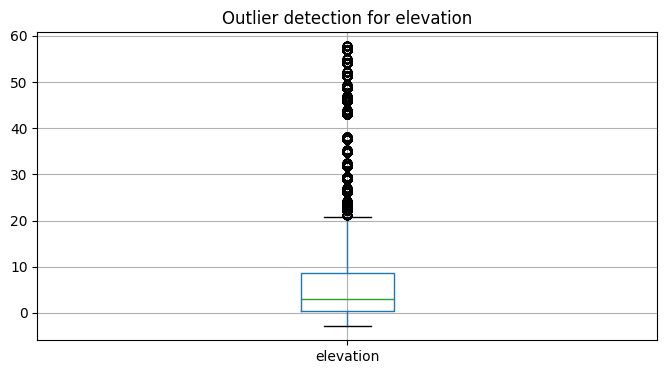

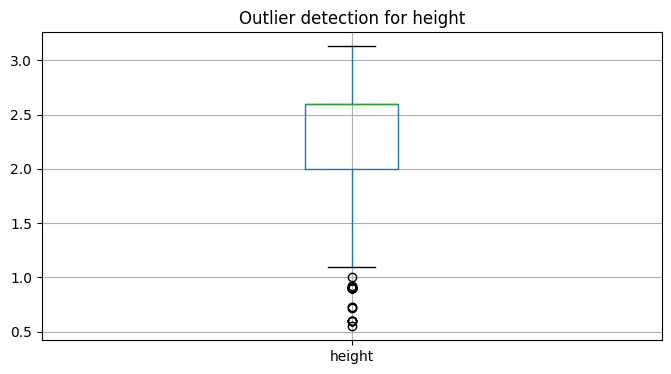

In [6]:
numerical_cols = ['elevation', 'height']

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=[col])
    plt.title(f'Outlier detection for {col}')
    plt.show()

In [7]:
df['roomtype'].unique()

<StringArray>
[     'Bathroom',    'Livingroom',       'Bedroom',       'Kitchen',
       'Balcony',      'Corridor',     'Structure',          'Door',
        'Window', 'Entrance Door',        'Dining',        'Stairs',
     'Storeroom']
Length: 13, dtype: str

In [8]:
print(df.isna().sum())

apartment_id      193367
site_id                0
building_id            0
plan_id                0
floor_id               0
unit_id           193367
area_id           883516
unit_usage             0
entity_type            0
entity_subtype         0
geom                   0
elevation              0
height                 0
zoning                 0
roomtype               0
split                  0
dtype: int64


**Convert to geopandas**

In [9]:
df['geom'] = df['geom'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geom')
gdf

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype,split
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,"POLYGON ((-2.73378 4.07981, -1.7053 5.30551, -...",0.0,2.6,Zone3,Bathroom,train
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,"POLYGON ((5.8279 7.81688, 3.64914 5.22033, 0.4...",0.0,2.6,Zone2,Livingroom,train
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,"POLYGON ((6.75571 2.41337, 6.42279 2.69272, 5....",0.0,2.6,Zone1,Bedroom,train
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,"POLYGON ((3.58212 5.14046, 1.60055 2.77892, -1...",0.0,2.6,Zone2,Kitchen,train
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.01414 4.18206, 6.13291 1.56509, 3....",0.0,2.6,Zone1,Bedroom,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086841,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,"POLYGON ((-1.42983 3.3319, -1.42983 3.37147, -...",14.5,2.0,Door,Door,test
1086842,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,"POLYGON ((-3.50232 3.3319, -3.50232 3.37147, -...",14.5,2.0,Entrance Door,Entrance Door,test
1086843,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,"POLYGON ((0.52836 5.78634, 0.58111 5.78634, 0....",15.0,1.9,Window,Window,test
1086844,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,"POLYGON ((-3.62793 5.80601, -3.62793 5.85877, ...",15.0,1.9,Window,Window,test


**Perimeters**

In [10]:
# 1. Filter the entire dataset to keep only the rooms (areas)
all_rooms = df[df['entity_type'] == 'area'].copy()

# 2. Ensure it is a GeoDataFrame and set the geometry column
if not isinstance(all_rooms, gpd.GeoDataFrame):
    # Note: if 'geom' is pure text (WKT), you first need to convert it using shapely.wkt.loads
    # but assuming you already have valid geometry objects:
    all_rooms = gpd.GeoDataFrame(all_rooms, geometry='geom')

# 3. function that performs the contour
def generate_outline(room_geometries, wall_bridge_distance=0.3):
    return room_geometries.buffer(wall_bridge_distance).union_all().buffer(-wall_bridge_distance)

# 4. Apply the contour function to the whole dataset by grouping by 'unit_id'
print("Calculating all outlines... (this might take a few seconds)")
all_outlines = all_rooms.groupby('unit_id')['geom'].apply(generate_outline).reset_index()

# 5. Convert the result back into a clean GeoDataFrame
complete_outline_gdf = gpd.GeoDataFrame(all_outlines, geometry='geom')

print("Done! You have calculated the outlines for all apartments.")
complete_outline_gdf

Calculating all outlines... (this might take a few seconds)
Done! You have calculated the outlines for all apartments.


,unit_id,geom
0,4967.0,"POLYGON ((2.65476 5.19864, 2.6554 5.19901, 2.6..."
1,4969.0,"POLYGON ((-10.47718 4.67842, -10.47022 4.67937..."
2,4970.0,"POLYGON ((2.2429 5.52181, 2.25104 5.52657, 2.2..."
3,4971.0,"POLYGON ((-5.61788 -4.74761, -5.61092 -4.74665..."
4,4973.0,"POLYGON ((2.70623 5.21384, 2.71769 5.22048, 2...."
...,...,...
18897,161620.0,"POLYGON ((2.25378 0.04359, 2.25418 0.05061, 2...."
18898,161621.0,"POLYGON ((-6.4057 -3.56157, -6.4053 -3.55456, ..."
18899,161622.0,"POLYGON ((-11.45622 -3.02478, -11.45582 -3.017..."
18900,161623.0,"POLYGON ((2.25378 0.04359, 2.25418 0.05061, 2...."


**Colors**

In [11]:
all_rooms['room_id'] = all_rooms['entity_subtype'].apply(
    lambda x: ROOM_NAMES.index(ROOM_MAPPING.get(x, 'Livingroom')) if ROOM_MAPPING.get(x, 'Livingroom') in ROOM_NAMES else 0
)


# Plot example

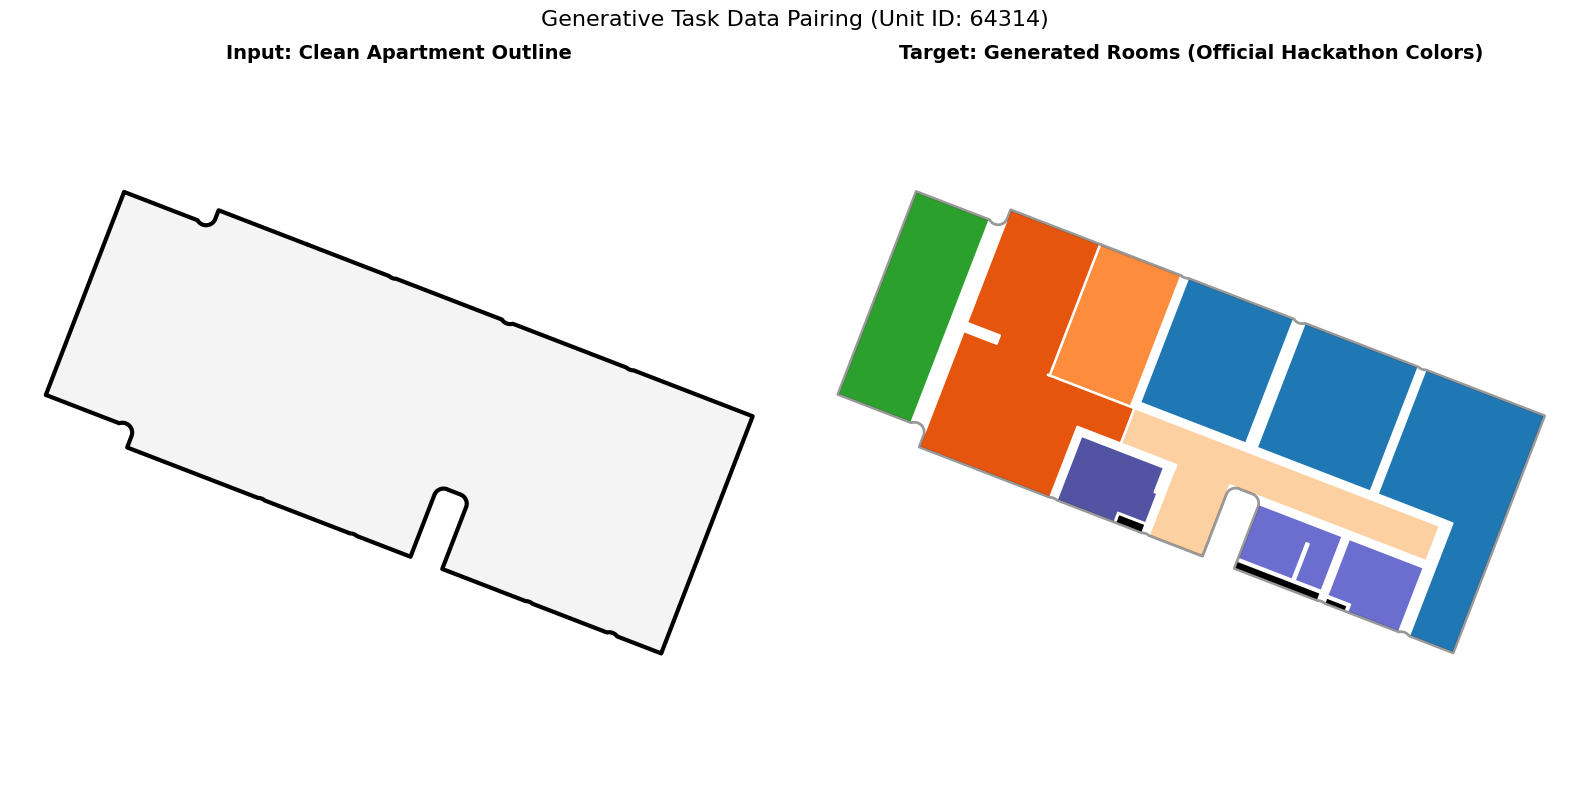

In [12]:
sample_unit_id = 64314


rooms_to_plot = all_rooms[all_rooms['unit_id'] == sample_unit_id].copy()
outline_to_plot = complete_outline_gdf[complete_outline_gdf['unit_id'] == sample_unit_id]


rooms_to_plot['room_id'] = rooms_to_plot['entity_subtype'].apply(
    lambda x: ROOM_NAMES.index(ROOM_MAPPING.get(str(x).strip(), 'Livingroom')) if ROOM_MAPPING.get(str(x).strip(), 'Livingroom') in ROOM_NAMES else 0
)


rooms_to_plot['hex_color'] = rooms_to_plot['room_id'].apply(lambda x: COLORS_ROOMTYPE[x])

# 4. PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


outline_to_plot.plot(ax=ax1, facecolor='#f4f4f4', edgecolor='black', linewidth=3)
ax1.set_title("Input: Clean Apartment Outline", fontsize=14, fontweight='bold')
ax1.axis('equal')
ax1.axis('off')


rooms_to_plot.plot(ax=ax2, color=rooms_to_plot['hex_color'].tolist(), edgecolor='white', linewidth=1.5)
outline_to_plot.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=2, alpha=0.4)
ax2.set_title("Target: Generated Rooms (Official Hackathon Colors)", fontsize=14, fontweight='bold')
ax2.axis('equal')
ax2.axis('off')

plt.suptitle(f"Generative Task Data Pairing (Unit ID: {sample_unit_id})", fontsize=16)
plt.tight_layout()
plt.show()

# Model

rows: 1,086,846
columns: 17


,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
0,0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,"POLYGON ((-2.7337844078265210 4.0798074408321536, -1.7052982090605919 5.3055095631450140, -1.1780751324833911 4.8631...",0.0,2.6,Zone3,Bathroom
1,1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,"POLYGON ((5.8278988701887320 7.8168767234029719, 3.6491356898434804 5.2203278758145313, 0.4650811028512205 7.8920669...",0.0,2.6,Zone2,Livingroom
2,2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,"POLYGON ((6.7557107205191187 2.4133695948125862, 6.4227908015236199 2.6927225760532796, 5.8202647635534994 1.9746600...",0.0,2.6,Zone1,Bedroom
3,3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,"POLYGON ((3.5821200013910017 5.1404616883411176, 1.6005471607450650 2.7789151365142057, -1.5835074262471949 5.450654...",0.0,2.6,Zone2,Kitchen
4,4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.0141380455489282 4.1820568551516661, 6.1329142170518764 1.5650929199190529, 3.8007807724960490 -1.214235...",0.0,2.6,Zone1,Bedroom


,dtype
Unnamed: 0.1,int64
Unnamed: 0,int64
apartment_id,str
site_id,int64
building_id,int64
plan_id,int64
floor_id,int64
unit_id,float64
area_id,float64
unit_usage,str


,missing,missing_pct,n_unique,dtype
Unnamed: 0.1,0,0.00,1086846,int64
Unnamed: 0,0,0.00,1086846,int64
apartment_id,193367,17.79,18269,str
site_id,0,0.00,1130,int64
building_id,0,0.00,2550,int64
plan_id,0,0.00,5372,int64
floor_id,0,0.00,5372,int64
unit_id,193367,17.79,18902,float64
area_id,883516,81.29,203330,float64
unit_usage,0,0.00,2,str


,rows
entity_type,
separator,602196
opening,281320
area,203330


...

,rows
roomtype,
Structure,640185
Door,135619
Window,103173
Bedroom,42584
Entrance Door,42528
Bathroom,28276
Corridor,25738
Balcony,19783
Kitchen,18000


,n_unique
site_id,1130
building_id,2550
floor_id,5372
plan_id,5372
apartment_id,18269
unit_id,18902
area_id,203330


,value
area_rows,203330
plans_with_rooms,5372
invalid_geometries,0
empty_geometries,0
zero_or_negative_area,0


,plan_id,entity_subtype,roomtype,area_m2,perimeter_m,n_exterior_vertices,geometry
0,1054,BATHROOM,Bathroom,3.515454,7.934030,7,"POLYGON ((-2.73378 4.07981, -1.7053 5.30551, -1.17808 4.86312, -1.28215 4.73909, 0.00384 3.66002, -0.92058 2.55835, ..."
1,1054,LIVING_ROOM,Livingroom,14.088640,15.092084,5,"POLYGON ((5.8279 7.81688, 3.64914 5.22033, 0.46508 7.89207, 2.64384 10.48862, 5.8279 7.81688))"
2,1054,ROOM,Bedroom,17.214329,16.966812,9,"POLYGON ((6.75571 2.41337, 6.42279 2.69272, 5.82026 1.97466, 3.08663 4.26845, 5.96652 7.70056, 8.69362 5.41225, 8.23..."
3,1054,KITCHEN,Kitchen,12.813539,14.478536,5,"POLYGON ((3.58212 5.14046, 1.60055 2.77892, -1.58351 5.45065, 0.39807 7.8122, 3.58212 5.14046))"
4,1054,ROOM,Bedroom,14.771212,15.398857,5,"POLYGON ((3.01414 4.18206, 6.13291 1.56509, 3.80078 -1.21424, 0.682 1.40273, 3.01414 4.18206))"


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
area_m2,203330.0,9.178842,11.053603,0.001269,0.031949,0.119154,2.305510,6.900080,13.621307,26.634443,40.603755,1991.878585
perimeter_m,203330.0,11.962130,7.894435,0.172140,0.735108,1.636079,6.597524,11.509975,15.798164,24.804063,35.594985,311.069959
width_m,203330.0,3.600597,2.342263,0.026404,0.195255,0.451724,1.958816,3.380204,4.954051,7.314297,10.566675,102.164839
height_m,203330.0,3.596264,2.323458,0.023891,0.195823,0.455494,1.965514,3.372174,4.944910,7.355657,10.407376,117.666822
n_exterior_vertices,203330.0,8.926091,6.078383,4.000000,5.000000,5.000000,5.000000,7.000000,11.000000,20.000000,31.000000,276.000000


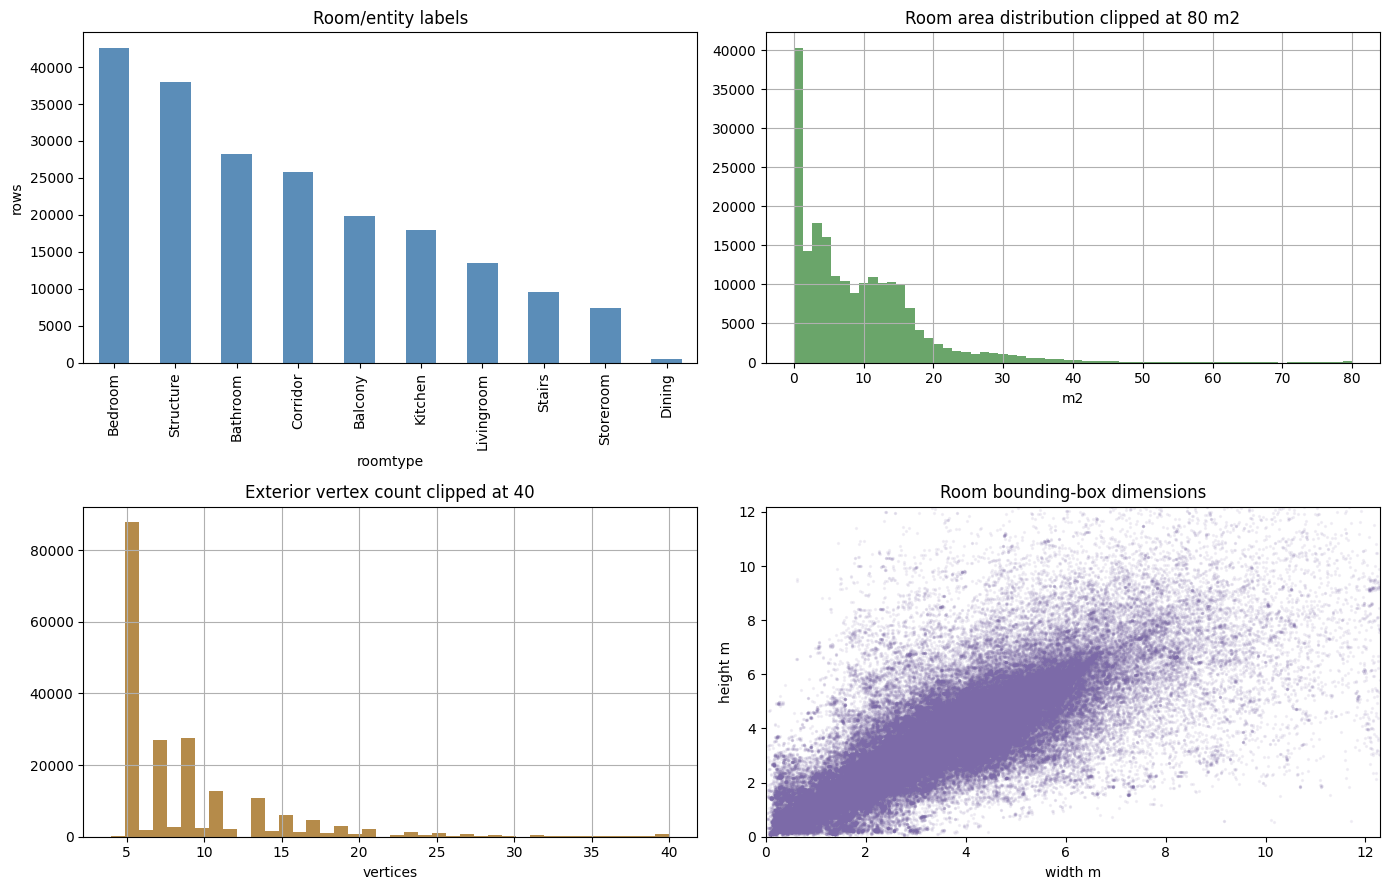

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
room_count,5372.0,37.849963,25.718580,15.000000,16.000000,18.000000,24.000000,31.000000,43.000000,77.000000,152.870000,400.000000
total_area_m2,5372.0,347.418837,248.057282,81.441462,139.055965,161.873067,209.903281,283.151686,397.821772,721.336883,1301.032360,3767.120054
mean_room_area_m2,5372.0,9.335468,2.711340,3.504373,5.072994,6.229195,8.018317,9.134216,10.324396,13.055583,16.317345,123.351063
max_room_area_m2,5372.0,34.431314,38.666746,11.397555,15.759882,17.498700,21.922341,29.536595,37.526258,60.059428,142.090069,1991.878585
unique_roomtypes,5372.0,7.921631,1.058519,2.000000,5.000000,6.000000,7.000000,8.000000,9.000000,9.000000,10.000000,10.000000
minx,5372.0,-13.173136,6.282747,-92.049838,-36.018738,-24.763804,-14.812590,-11.615476,-9.700312,-7.185723,-5.796063,9.771570
miny,5372.0,-13.495556,6.325351,-71.156685,-38.937791,-25.001256,-15.030461,-11.845731,-9.836189,-7.635145,-5.997505,4.693724
maxx,5372.0,13.222630,6.320531,-24.837381,5.786791,7.140488,9.615178,11.704750,14.718101,24.930832,38.116063,79.315203
maxy,5372.0,13.496328,6.838820,-42.407366,5.705294,7.357487,9.749886,11.816317,15.032410,26.086042,39.080486,75.185441
extent_width_m,5372.0,26.395766,12.221238,7.881905,12.183389,14.685913,19.363434,23.255601,29.358042,49.729554,73.972162,171.365042


,room_count,total_area_m2,mean_room_area_m2,max_room_area_m2,unique_roomtypes,minx,miny,maxx,maxy,extent_width_m,extent_height_m,extent_area_m2,roomtype_counts
plan_id,,,,,,,,,,,,,
288,15,188.021253,12.534750,21.152628,5,-6.109437,-11.016745,5.880275,10.912744,11.989711,21.929489,262.928242,"{(288, 'Bedroom'): 6, (288, 'Stairs'): 3, (288, 'Bathroom'): 2, (288, 'Livingroom'): 2, (288, 'Kitchen'): 2}"
8516,15,148.316285,9.887752,48.834769,8,-8.727067,-8.084819,8.329891,8.639229,17.056958,16.724048,285.261375,"{(8516, 'Bathroom'): 3, (8516, 'Corridor'): 3, (8516, 'Bedroom'): 3, (8516, 'Stairs'): 2, (8516, 'Kitchen'): 1, (851..."
6458,15,165.267503,11.017834,21.531792,5,-9.571077,-8.087135,10.165973,7.045751,19.737049,15.132886,298.678528,"{(6458, 'Bedroom'): 6, (6458, 'Corridor'): 3, (6458, 'Kitchen'): 2, (6458, 'Bathroom'): 2, (6458, 'Balcony'): 2}"
15878,15,136.053583,9.070239,14.659506,7,-8.634340,-8.279247,8.826153,8.094456,17.460493,16.373703,285.892935,"{(15878, 'Bedroom'): 4, (15878, 'Corridor'): 2, (15878, 'Balcony'): 2, (15878, 'Livingroom'): 2, (15878, 'Bathroom')..."
15883,15,152.775785,10.185052,18.254773,7,-9.473476,-8.700357,9.147214,8.555906,18.620690,17.256263,321.323519,"{(15883, 'Bedroom'): 4, (15883, 'Kitchen'): 2, (15883, 'Bathroom'): 2, (15883, 'Livingroom'): 2, (15883, 'Balcony'):..."


,room_count,total_area_m2,mean_room_area_m2,max_room_area_m2,unique_roomtypes,minx,miny,maxx,maxy,extent_width_m,extent_height_m,extent_area_m2,roomtype_counts
plan_id,,,,,,,,,,,,,
9374,400,3633.258886,9.083147,61.150650,9,-90.897147,-57.699364,78.321980,73.686409,169.219127,131.385773,22232.985847,"{(9374, 'Bedroom'): 81, (9374, 'Structure'): 77, (9374, 'Bathroom'): 64, (9374, 'Corridor'): 34, (9374, 'Balcony'): ..."
9375,398,3724.875293,9.358983,62.711874,9,-92.049838,-58.431071,79.315203,74.620849,171.365042,133.051920,22800.447828,"{(9375, 'Bedroom'): 82, (9375, 'Structure'): 77, (9375, 'Bathroom'): 64, (9375, 'Corridor'): 31, (9375, 'Kitchen'): ..."
6832,388,3767.120054,9.709072,38.143782,8,-89.573160,-59.420626,77.259512,75.185441,166.832672,134.606067,22456.689828,"{(6832, 'Bedroom'): 128, (6832, 'Bathroom'): 63, (6832, 'Structure'): 57, (6832, 'Balcony'): 46, (6832, 'Corridor'):..."
2968,258,2413.711584,9.355471,40.592675,8,-41.733915,-51.600921,35.814950,69.409228,77.548865,121.010149,9384.199707,"{(2968, 'Structure'): 57, (2968, 'Balcony'): 43, (2968, 'Bedroom'): 40, (2968, 'Bathroom'): 35, (2968, 'Corridor'): ..."
2969,258,2418.346675,9.373437,40.602592,8,-41.735919,-51.647842,35.818521,69.370146,77.554440,121.017988,9385.482287,"{(2969, 'Structure'): 58, (2969, 'Balcony'): 42, (2969, 'Bedroom'): 40, (2969, 'Bathroom'): 35, (2969, 'Corridor'): ..."


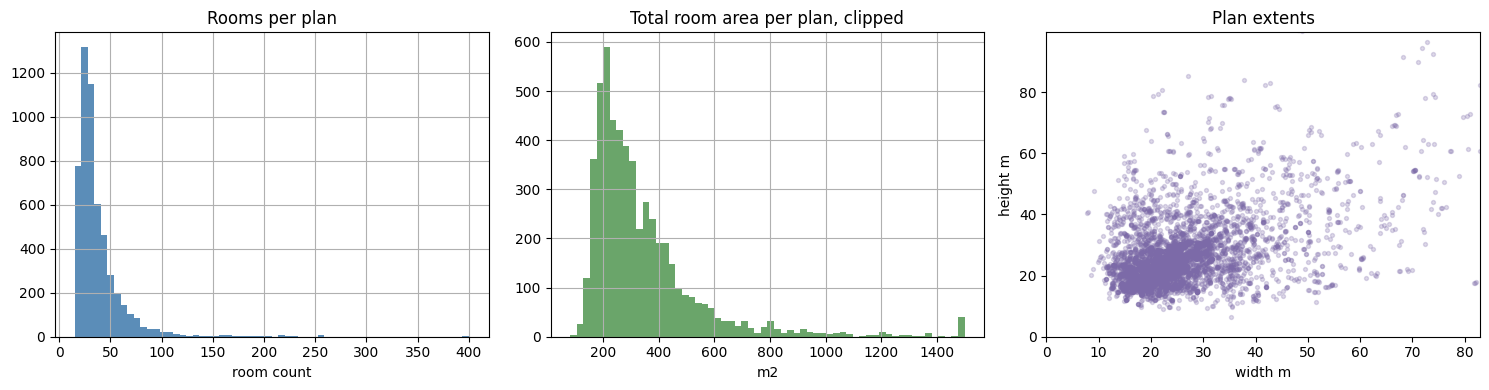

,plan_presence_rate
roomtype,
Bathroom,99.8%
Corridor,99.4%
Bedroom,98.6%
Kitchen,98.0%
Structure,93.0%
Balcony,91.6%
Stairs,83.7%
Livingroom,80.0%
Storeroom,43.5%


roomtype,Balcony,Bathroom,Bedroom,Corridor,Dining,Kitchen,Livingroom,Stairs,Storeroom,Structure
roomtype,,,,,,,,,,
Balcony,4919,4915,4868,4891,211,4870,4030,4174,2112,4600
Bathroom,4915,5362,5295,5328,240,5265,4299,4495,2332,4988
Bedroom,4868,5295,5298,5272,237,5198,4232,4460,2297,4944
Corridor,4891,5328,5272,5338,241,5232,4274,4469,2323,4966
Dining,211,240,237,241,241,241,203,208,114,236
Kitchen,4870,5265,5198,5232,241,5266,4298,4460,2284,4903
Livingroom,4030,4299,4232,4274,203,4298,4300,3780,1989,4033
Stairs,4174,4495,4460,4469,208,4460,3780,4499,2033,4224
Storeroom,2112,2332,2297,2323,114,2284,1989,2033,2338,2220


sample_plan_id: 7988
rooms: 45
outline geom type: Polygon
outline area m2: 483.56


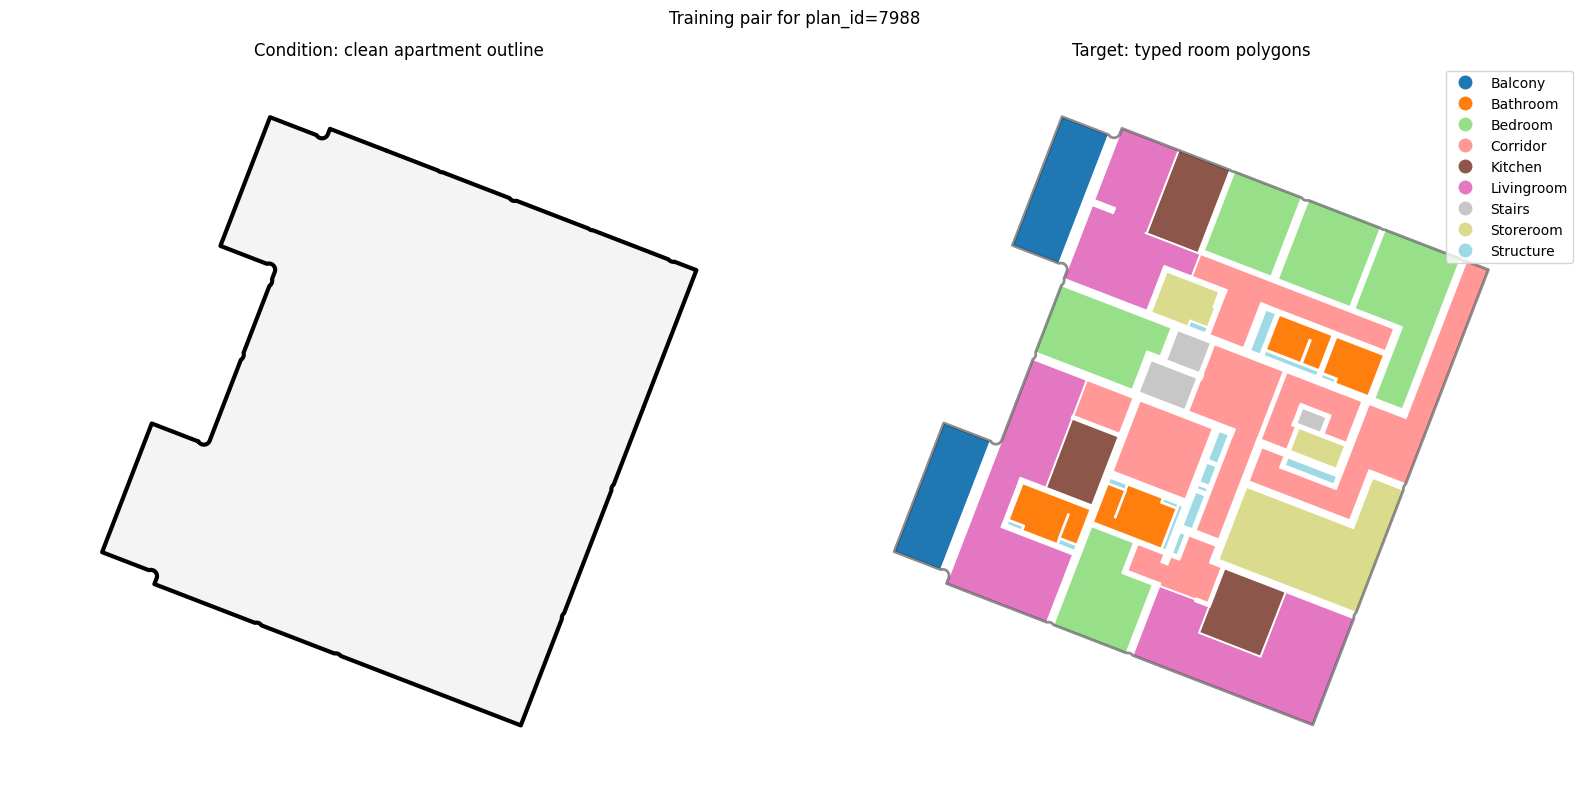

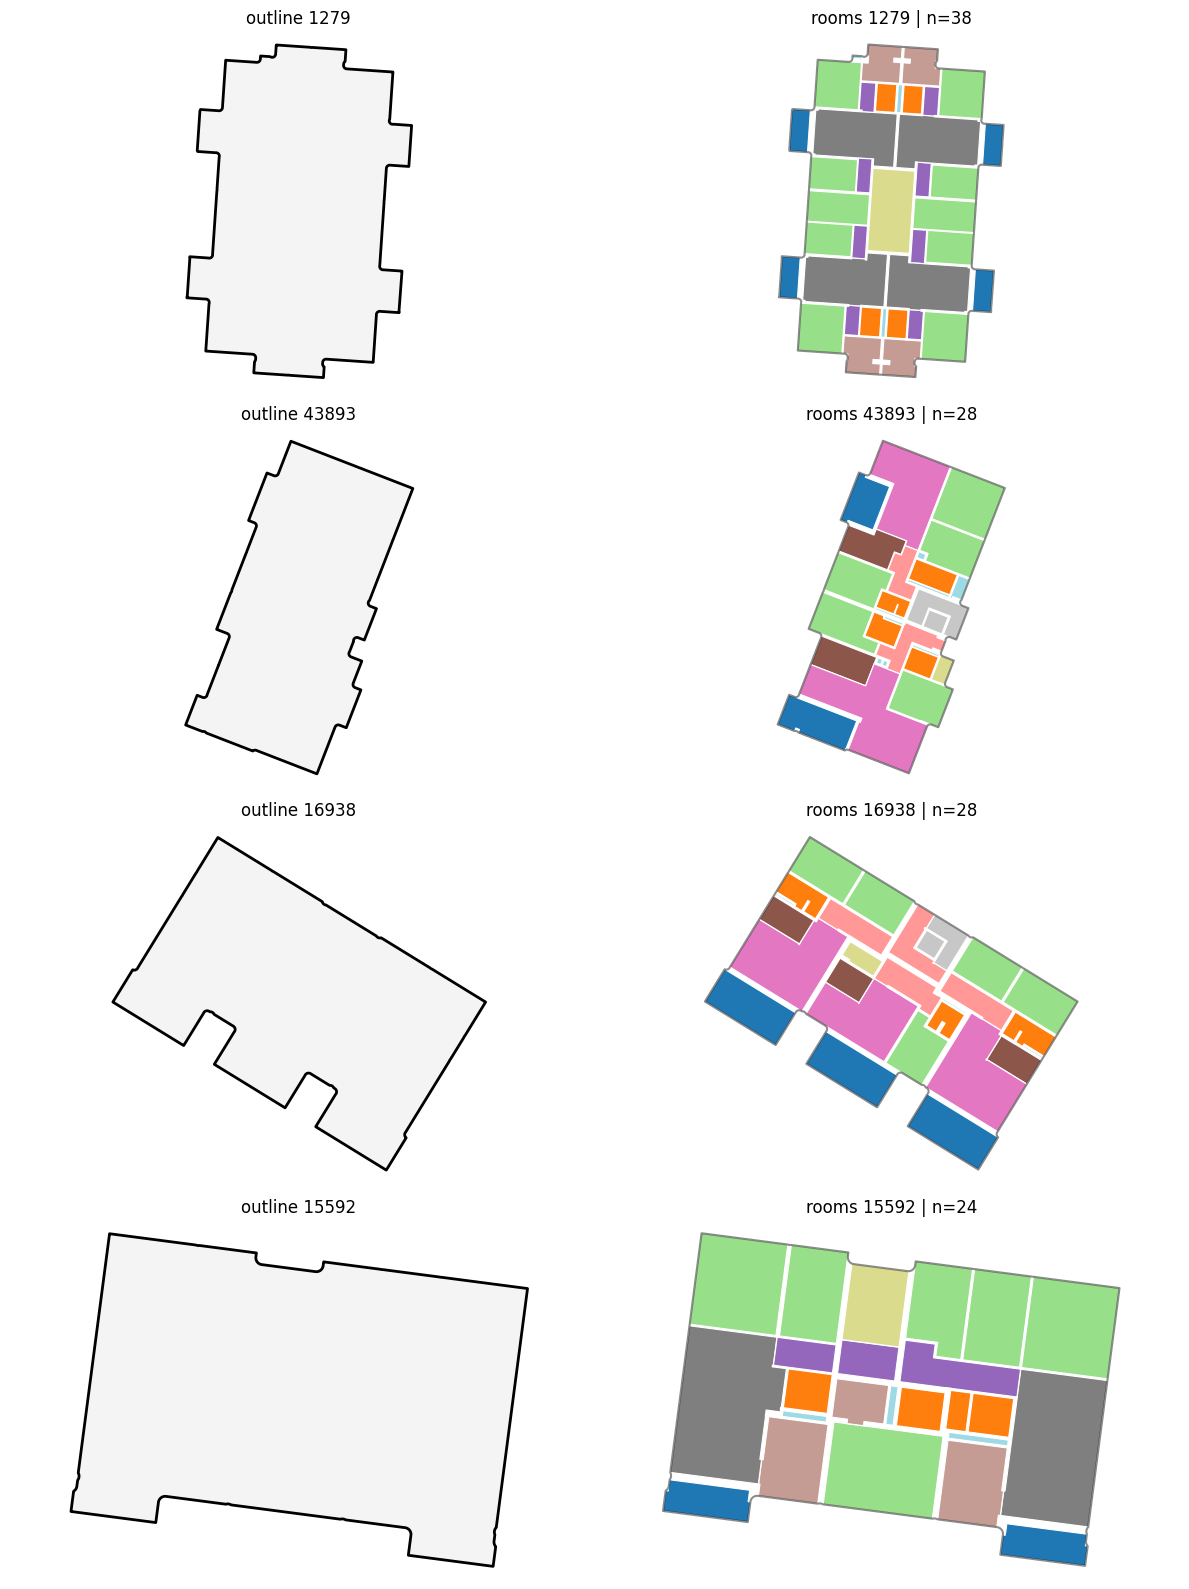

label ids: {'Balcony': 1, 'Bathroom': 2, 'Bedroom': 3, 'Corridor': 4, 'Dining': 5, 'Kitchen': 6, 'Livingroom': 7, 'Stairs': 8, 'Storeroom': 9, 'Structure': 10}
outline occupancy: 0.496
target occupancy: 0.434


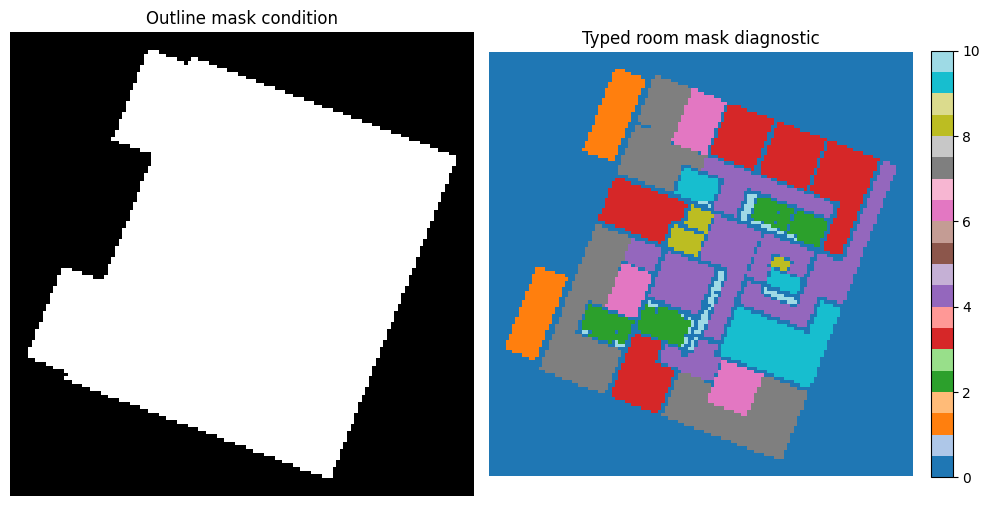

,representation,pros,risks,use_when
0,Typed polygon set,Matches required output directly; preserves geometry exactly,Variable number of rooms and vertices; needs set/sequence model and validity constraints,Final architecture or post-processed output format
1,Corner/vertex sequences,Vector-native and compact; can condition on outline tokens,"Requires ordering, padding, EOS tokens, and polygon repair",Diffusion/flow over fixed padded token tensors
2,Room boxes plus class labels,Simpler fixed-size target; good baseline for room placement,Loses non-rectangular room shape; vector refinement still needed,Fast baseline or first-stage layout proposal
3,Raster semantic masks,Fits standard image diffusion; easy conditioning on outline mask,"Submission is not pixels; needs polygonization, label cleanup, and topology repair","Prototype, ablation, or first-stage generator"


,decision implication
conditioning,Use the 0.3 m buffer-union-buffer outline as the only fixed input condition.
target,Train on entity_type == area rows grouped by plan_id; output typed room polygons.
normalization,Normalize coordinates per outline bounds or centroid/scale because plans vary strongly in extent and area.
imbalance,Room labels are imbalanced; monitor rare labels and density/coverage to avoid mode collapse.
fixed_tensor_options,Pad room/corner sequences or train a raster semantic-mask baseline with vectorization afterward.
evaluation_alignment,"FID and density/coverage reward realism and diversity, so keep stochastic sampling with seed 42 and inspect distribu..."


,plans,sites,buildings,share_building_with_train,share_site_with_train
split,,,,,
train,4299,904,2015,1.0,1.0
val,542,113,275,0.0,0.0
test,531,113,260,0.0,0.0


quantization and bit roundtrips passed


,count,mean,std,min,50%,75%,90%,95%,99%,max
roomtype,,,,,,,,,,
Balcony,19783.0,9.90,6.56,4.0,9.0,11.0,16.0,20.0,37.00,155.0
Bathroom,28276.0,7.42,3.20,5.0,7.0,9.0,11.0,13.0,19.00,42.0
Bedroom,42584.0,7.79,3.98,5.0,7.0,9.0,13.0,15.0,23.00,66.0
Corridor,25738.0,13.44,8.20,5.0,11.0,17.0,23.0,27.0,39.00,276.0
Dining,540.0,10.18,4.93,5.0,9.0,12.0,17.0,19.0,25.61,42.0
Kitchen,18000.0,9.34,4.30,5.0,9.0,11.0,15.0,17.0,24.00,74.0
Livingroom,13492.0,15.44,8.23,5.0,14.0,19.0,26.0,31.0,41.00,107.0
Stairs,9561.0,8.95,9.24,4.0,5.0,10.0,17.0,21.0,36.00,239.0
Storeroom,7367.0,6.69,3.10,4.0,5.0,7.0,10.0,13.0,19.00,73.0


,roomtype,n_exterior_vertices,count
0,Balcony,4,7
1,Balcony,5,5371
2,Balcony,6,297
3,Balcony,7,3158
4,Balcony,8,471
5,Balcony,9,3262
6,Balcony,10,392
7,Balcony,11,1965
8,Balcony,12,290
9,Balcony,13,1543


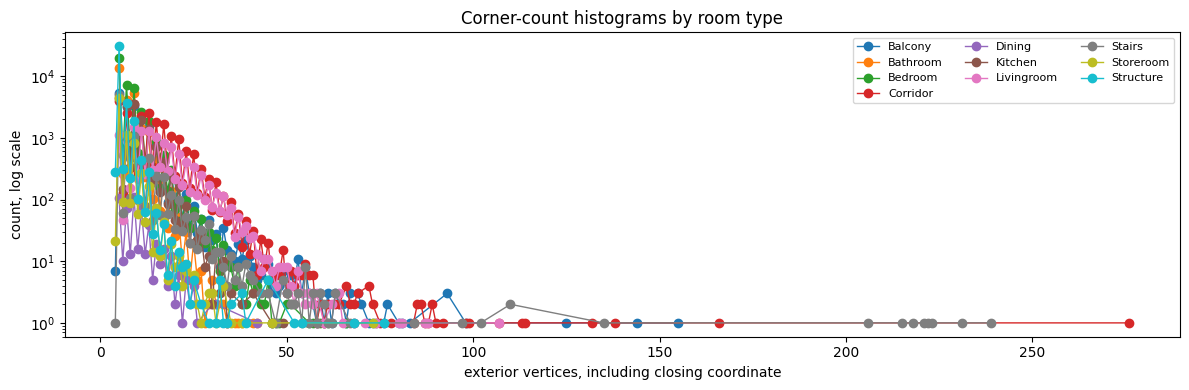

,plan_id,room_index,roomtype,roomtype_id,n_corners,area_m2
0,7988,0,Balcony,1,4,16.043892
1,7988,1,Balcony,1,4,15.987705
2,7988,2,Bathroom,2,16,7.489974
3,7988,3,Bathroom,2,14,6.864911
4,7988,4,Bathroom,2,8,4.951011


,plan_id,room_index,corner_index,roomtype,roomtype_id,x_grid,y_grid,x_cont,y_cont
0,7988,0,0,Balcony,1,5,75,-0.960784,-0.411765
1,7988,0,1,Balcony,1,25,127,-0.803922,-0.003922
2,7988,0,2,Balcony,1,45,119,-0.647059,-0.066667
3,7988,0,3,Balcony,1,24,67,-0.811765,-0.474510
4,7988,1,0,Balcony,1,54,198,-0.576471,0.552941
5,7988,1,1,Balcony,1,74,250,-0.419608,0.960784
6,7988,1,2,Balcony,1,93,243,-0.270588,0.905882
7,7988,1,3,Balcony,1,73,191,-0.427451,0.498039
8,7988,2,0,Bathroom,2,87,87,-0.317647,-0.317647
9,7988,2,1,Bathroom,2,93,102,-0.270588,-0.200000


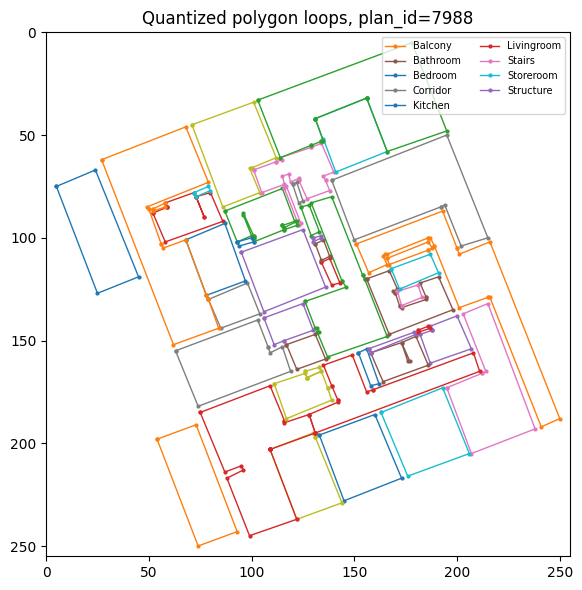

{'MAX_ROOMS': 76, 'MAX_CORNERS': 20}
coords (76, 20, 2) float32
grid (76, 20, 2) int64
bits (76, 20, 2, 8) float32
corner_mask (76, 20) bool
room_mask (76,) bool
roomtype_ids (76,) int64
outline_cont (295, 2) float32
bounds (4,) float32
plan_id int


/root/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


{'loss': 2.8284, 'noise_loss': 2.1285, 'bit_loss': 0.8935, 'roomtype_loss': 2.7281}
plan_id=10 expected rooms=53.4, expected coverage=0.91


,source_plan_id,outline_distance,rank,candidate_score,program_room_count,predicted_coverage,expected_coverage,program_room_count_error,program_roomtype_count_error,program_coverage_error,naturalness_penalty,candidate_rank
0,3933.0,0.717,39.0,0.869,53.404,0.853,0.91,0.026,0.205,0.057,0.279,1
1,3925.0,0.849,71.0,1.023,53.404,0.836,0.91,0.045,0.186,0.073,0.355,2
2,1436.0,0.831,64.0,1.036,53.404,0.847,0.91,0.064,0.243,0.063,0.303,3
3,41155.0,0.803,55.0,1.045,53.404,0.837,0.91,0.008,0.315,0.073,0.326,4
4,41154.0,0.810,58.0,1.077,53.404,0.835,0.91,0.026,0.334,0.074,0.302,5
5,41153.0,0.807,57.0,1.077,53.404,0.835,0.91,0.026,0.334,0.075,0.304,6
6,1434.0,0.842,70.0,1.104,53.404,0.848,0.91,0.120,0.235,0.062,0.304,7
7,1430.0,0.840,69.0,1.110,53.404,0.844,0.91,0.120,0.235,0.065,0.304,8


plan_id=118 expected rooms=53.4, expected coverage=0.91


,source_plan_id,outline_distance,rank,candidate_score,program_room_count,predicted_coverage,expected_coverage,program_room_count_error,program_roomtype_count_error,program_coverage_error,naturalness_penalty,candidate_rank
0,3933.0,0.720,39.0,0.870,53.372,0.853,0.91,0.026,0.205,0.057,0.278,1
1,3925.0,0.852,73.0,1.024,53.372,0.836,0.91,0.044,0.186,0.073,0.354,2
2,1436.0,0.828,64.0,1.034,53.372,0.847,0.91,0.063,0.243,0.063,0.302,3
3,41155.0,0.800,55.0,1.042,53.372,0.837,0.91,0.007,0.315,0.073,0.326,4
4,41154.0,0.807,58.0,1.074,53.372,0.835,0.91,0.026,0.334,0.074,0.302,5
5,41153.0,0.804,56.0,1.075,53.372,0.835,0.91,0.026,0.334,0.075,0.304,6
6,1434.0,0.839,70.0,1.101,53.372,0.848,0.91,0.119,0.235,0.062,0.303,7
7,1430.0,0.837,69.0,1.107,53.372,0.844,0.91,0.119,0.235,0.065,0.304,8


plan_id=141 expected rooms=52.8, expected coverage=0.91


,source_plan_id,outline_distance,rank,candidate_score,program_room_count,predicted_coverage,expected_coverage,program_room_count_error,program_roomtype_count_error,program_coverage_error,naturalness_penalty,candidate_rank
0,3933.0,0.752,50.0,0.888,52.803,0.851,0.91,0.004,0.226,0.059,0.292,1
1,1436.0,0.773,54.0,1.000,52.803,0.838,0.91,0.053,0.239,0.072,0.293,2
2,3925.0,0.857,80.0,1.011,52.803,0.836,0.91,0.034,0.188,0.074,0.345,3
3,1434.0,0.784,59.0,1.044,52.803,0.839,0.91,0.091,0.211,0.071,0.324,4
4,1430.0,0.783,57.0,1.049,52.803,0.836,0.91,0.091,0.211,0.074,0.322,5
5,1438.0,0.794,62.0,1.054,52.803,0.836,0.91,0.091,0.211,0.074,0.321,6
6,41155.0,0.817,70.0,1.064,52.803,0.832,0.91,0.004,0.322,0.079,0.327,7
7,5034.0,0.647,26.0,1.086,52.803,0.845,0.91,0.129,0.274,0.065,0.374,8


,plan_id,source_plan_id,match_rank,candidate_rank,candidate_score,outline_distance,sample_index,target_rooms,predicted_rooms,room_count_error,roomtype_count_l1,mean_best_same_type_iou,target_area_m2,predicted_area_m2,outline_area_m2,union_iou,prediction_outline_coverage
0,10.0,3933.0,39.0,1.0,0.869,0.717,0.0,65.0,52.0,-13.0,19.0,0.097,513.143,484.347,567.959,0.776,0.853
1,10.0,1434.0,70.0,7.0,1.104,0.842,1.0,65.0,47.0,-18.0,22.0,0.122,513.143,481.666,567.959,0.776,0.848
2,10.0,41154.0,58.0,5.0,1.077,0.810,2.0,65.0,52.0,-13.0,27.0,0.119,513.143,474.513,567.959,0.762,0.835
3,10.0,42281.0,17.0,12.0,1.188,0.615,3.0,65.0,44.0,-21.0,23.0,0.037,513.143,453.950,567.959,0.726,0.799
4,118.0,3933.0,39.0,1.0,0.870,0.720,0.0,65.0,52.0,-13.0,19.0,0.098,512.929,483.581,567.062,0.776,0.853
5,118.0,3925.0,73.0,2.0,1.024,0.852,1.0,65.0,51.0,-14.0,18.0,0.091,512.929,474.323,567.062,0.767,0.836
6,118.0,41154.0,58.0,5.0,1.074,0.807,2.0,65.0,52.0,-13.0,27.0,0.120,512.929,473.765,567.062,0.763,0.835
7,118.0,1438.0,72.0,9.0,1.112,0.849,3.0,65.0,47.0,-18.0,22.0,0.123,512.929,479.217,567.062,0.773,0.845
8,141.0,3933.0,50.0,1.0,0.888,0.752,0.0,65.0,53.0,-12.0,20.0,0.096,508.359,479.152,562.871,0.774,0.851
9,141.0,41153.0,71.0,10.0,1.088,0.820,1.0,65.0,52.0,-13.0,27.0,0.118,508.359,466.943,562.871,0.757,0.830


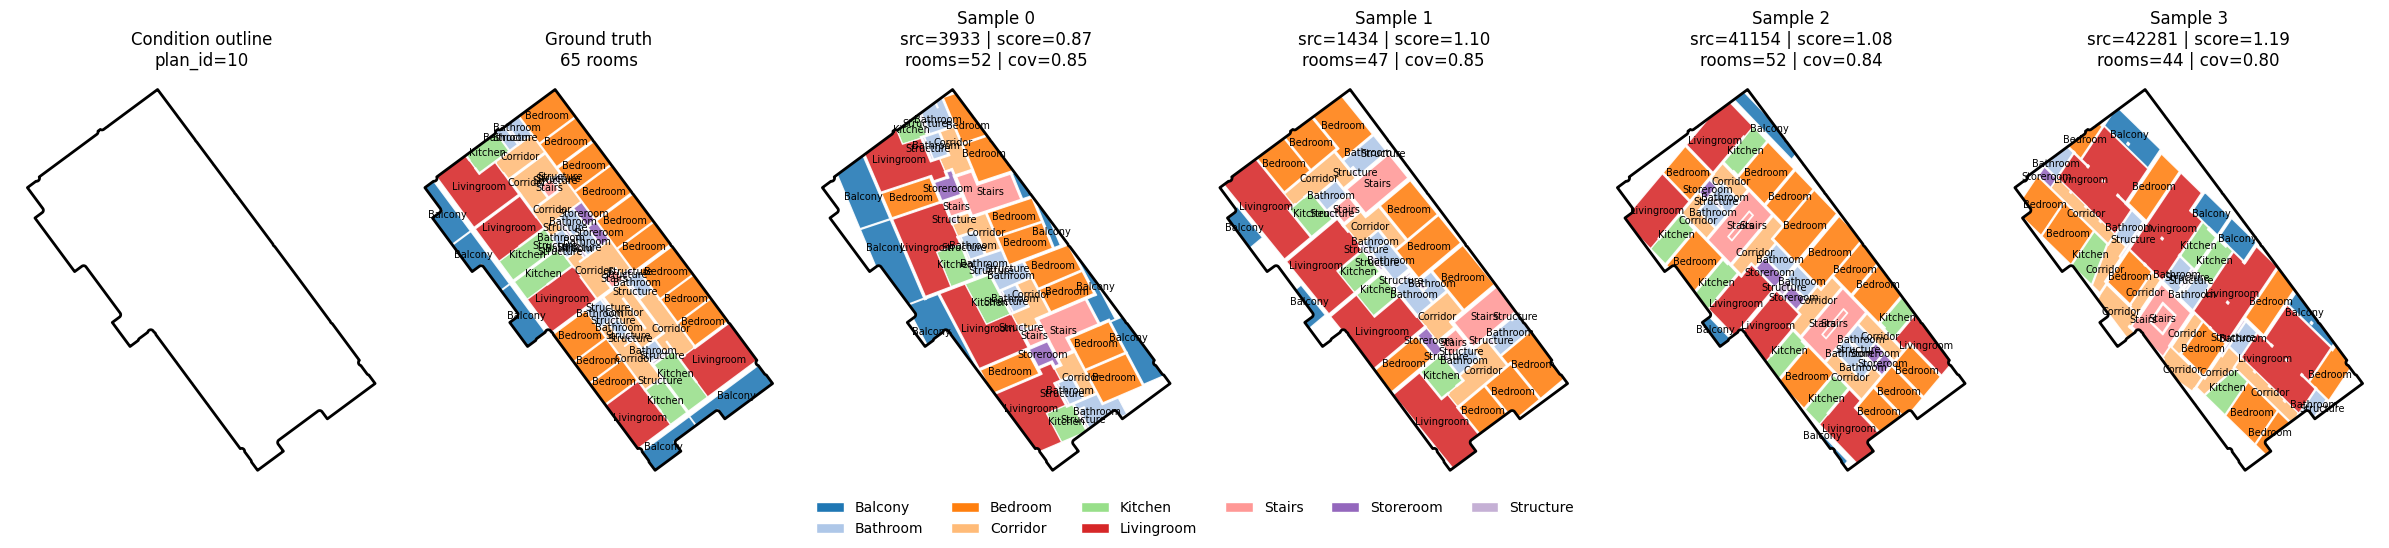

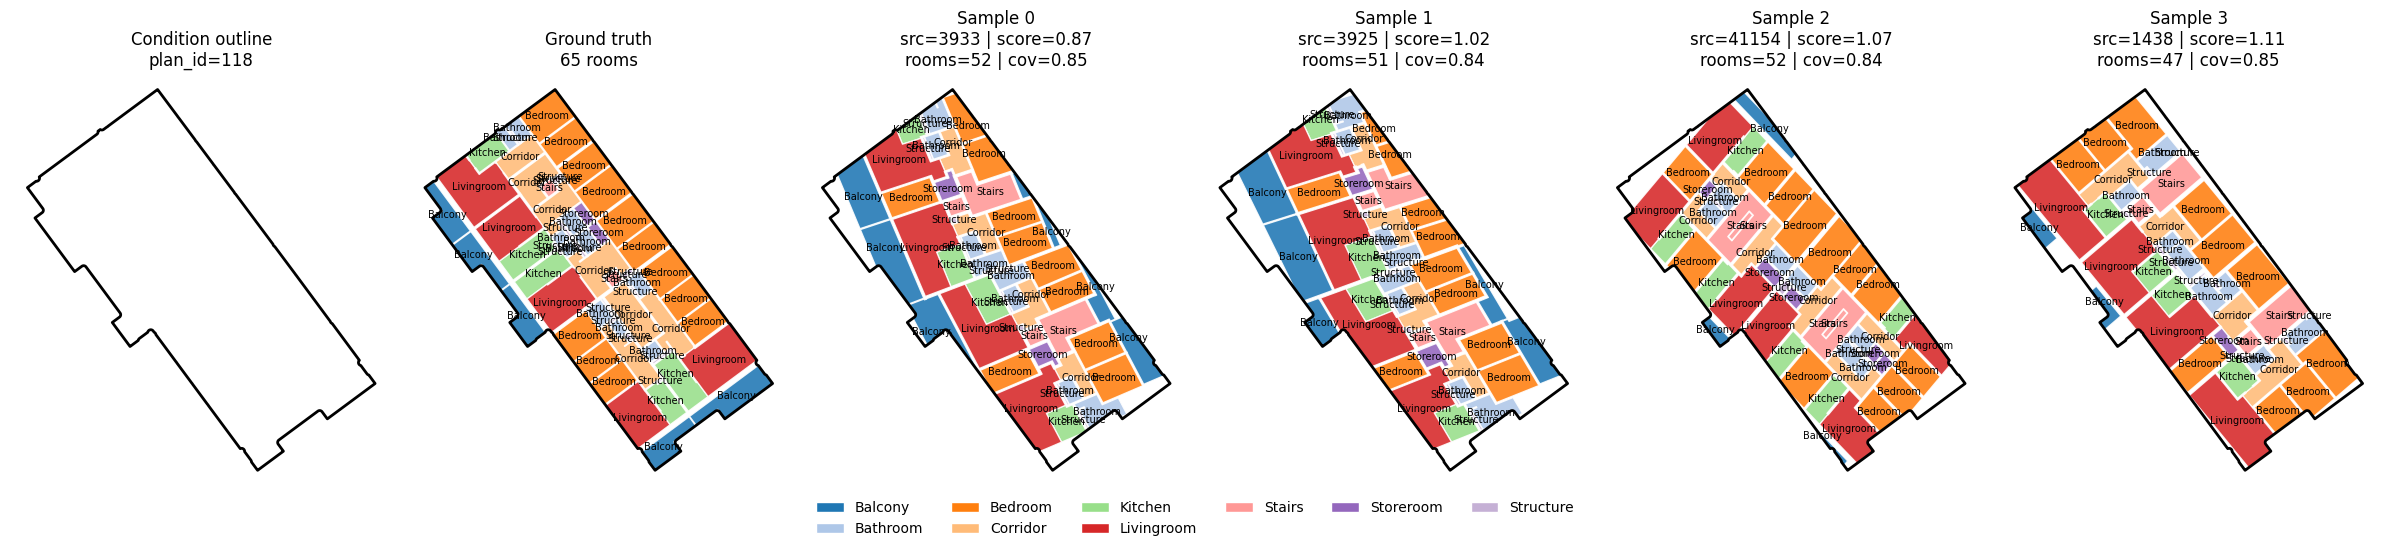

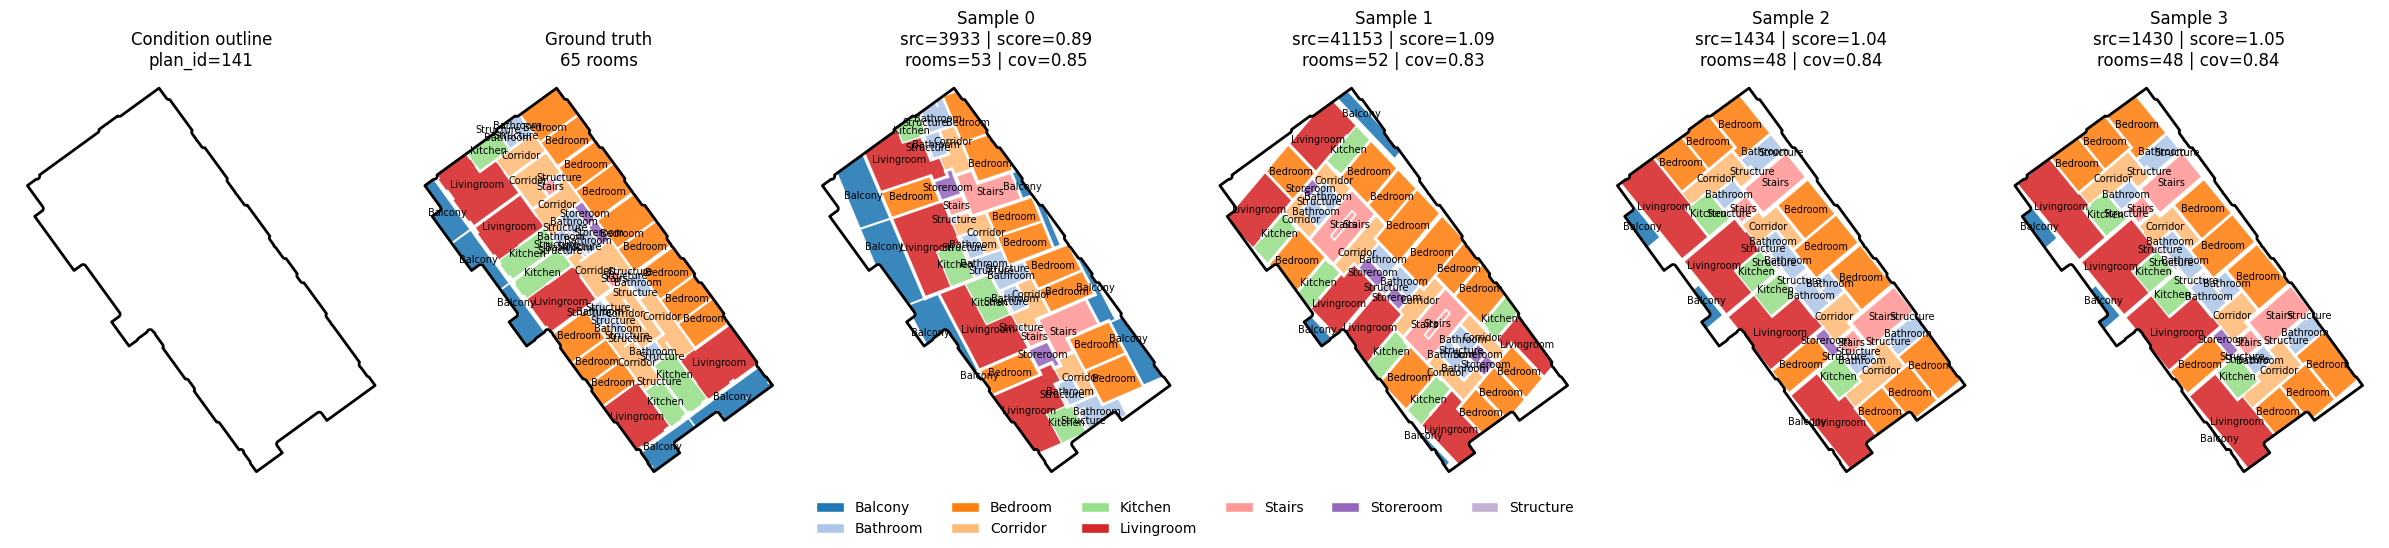

converted 45 polygons from padded arrays
loaded model checkpoint from artifacts/outline_conditioned_denoiser.pt
loaded model checkpoint from artifacts/outline_conditioned_denoiser.pt
Modello caricato correttamente da /root/artifacts/outline_conditioned_denoiser.pt
Planimetrie (plans) disponibili per la valutazione: 800


/tmp/ipykernel_60241/3350849098.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")
/root/venv/lib/python3.12/

In [15]:
import os
import shutil
from pathlib import Path
import json

# 1. Imposta la root del progetto
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "main.ipynb").exists() and (PROJECT_ROOT.parent / "main.ipynb").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

# 2. FIX: Copia il dataset dove main.ipynb si aspetta di trovarlo
local_csv_path = PROJECT_ROOT / "mds_V2_5.372k.csv"
if not local_csv_path.exists():
    print("Copiando il dataset dalla cache di Kaggle alla cartella del progetto...")
    # 'path' è la variabile che hai definito nel tuo primissimo blocco con kagglehub
    shutil.copy(path, local_csv_path) 
    print("Copia completata!")

# 3. Imposta i flag per non far partire l'addestramento indesiderato
RUN_DENOISER_TRAINING = False
TRAIN_IF_CHECKPOINT_MISSING = False
ENABLE_NEURAL_REFINEMENT = True
RUN_FINAL_COMPARISON = False

# 4. Esegui le definizioni di main.ipynb
%run -i main.ipynb

# 5. Definisci 'plan_ids' attingendo dal DataFrame creato nei blocchi precedenti
if 'df' in locals():
    plan_ids = df[df['split'] == 'test']['floor_id'].unique()
else:
    plan_ids = []
    print("Attenzione: Il DataFrame 'df' non è stato trovato in memoria.")

# 6. Carica il modello
MODEL_CHECKPOINT_PATH = Path("artifacts/outline_conditioned_denoiser.pt")

stored_model = load_outline_denoiser(MODEL_CHECKPOINT_PATH)
if stored_model is None:
    raise FileNotFoundError(
        f"Nessun modello trovato nel percorso {MODEL_CHECKPOINT_PATH}. "
        "Assicurati di aver eseguito main.ipynb almeno una volta con "
        "TRAIN_IF_CHECKPOINT_MISSING=True o RUN_DENOISER_TRAINING=True."
    )

print(f"Modello caricato correttamente da {MODEL_CHECKPOINT_PATH.resolve()}")
print(f"Planimetrie (plans) disponibili per la valutazione: {len(plan_ids):,}")


# Rendering

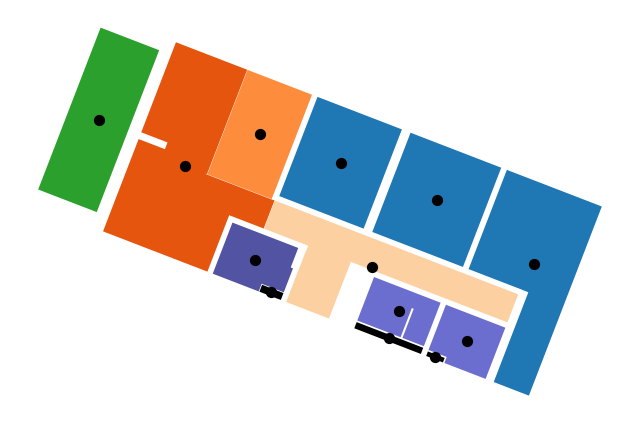

In [ ]:
sample_unit_id = 64314
rooms_to_plot = all_rooms[all_rooms['unit_id'] == sample_unit_id]

def convert_to_msd_graph(single_apartment_gdf):
    G = nx.Graph()
    
    for i, (index, row) in enumerate(single_apartment_gdf.iterrows(), start=1):
        polygon = row['geom'] if 'geom' in single_apartment_gdf.columns else row.geometry
        centroid = (polygon.centroid.x, polygon.centroid.y)
        
        raw_room_name = row.get('entity_subtype', 'LIVING_ROOM') 
        mapped_room_name = ROOM_MAPPING.get(str(raw_room_name).strip(), 'Livingroom')
        room_id = ROOM_NAMES.index(mapped_room_name) if mapped_room_name in ROOM_NAMES else 0
            
        G.add_node(i, geometry=polygon, room_type=room_id, centroid=centroid)
        
    return G

graph_for_judges = convert_to_msd_graph(rooms_to_plot)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal') 
ax.axis('off')    

plot.plot_floor(graph_for_judges, ax=ax, node_size=50, edge_size=3)


plt.show()


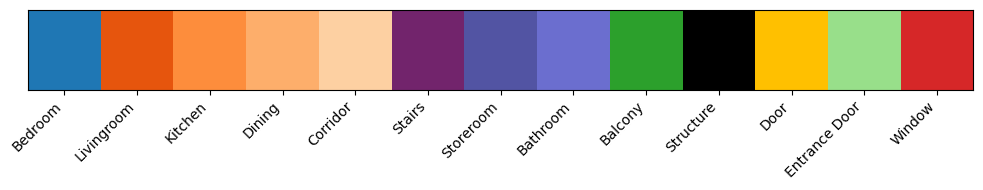

In [ ]:

n_rooms = len(ROOM_NAMES)
gradient = np.linspace(0, 1, n_rooms)
gradient = np.vstack((gradient, gradient))

fig, ax = plt.subplots(figsize=(10, 2))
ax.imshow(gradient, aspect='auto', cmap=CMAP_ROOMTYPE)


ax.set_xticks(np.arange(n_rooms))
ax.set_xticklabels(ROOM_NAMES, rotation=45, ha='right')
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Metrics

In [ ]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import json
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

EVALUATION_OUTPUT_DIR = Path("artifacts/dataset_metrics")
REAL_DIR = EVALUATION_OUTPUT_DIR / "real"
FAKE_DIR = EVALUATION_OUTPUT_DIR / "fake"
PER_PLAN_METRICS_PATH = EVALUATION_OUTPUT_DIR / "per_plan_model_metrics.csv"
SUMMARY_METRICS_PATH = EVALUATION_OUTPUT_DIR / "summary_model_metrics.json"

# --- MODIFICA QUI: Filtro esplicito per il TEST SET ---
# Prende in automatico gli ID unici delle planimetrie assegnate al test set dal DataFrame df
if 'df' in locals():
    test_plan_ids = df[df['split'] == 'test']['floor_id'].unique()
else:
    test_plan_ids = plan_ids # Fallback nel caso in cui df non fosse disponibile
    print("Attenzione: df non trovato, sto usando plan_ids generico.")

EVALUATION_PLAN_IDS = np.asarray(test_plan_ids, dtype=int)

# Set to a small integer for a quick notebook smoke run. Keep None for the full dataset.
EVALUATION_LIMIT = None
if EVALUATION_LIMIT is not None:
    EVALUATION_PLAN_IDS = EVALUATION_PLAN_IDS[:int(EVALUATION_LIMIT)]
# --------------------------------------------------------


def reset_dir(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def render_plan_gdf(plan_id, room_gdf, output_path, title=None):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    outline = get_plan_outline(int(plan_id))
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_room_polygons(ax, room_gdf, outline=outline, title=title or f"plan_id={plan_id}", show_labels=False)
    fig.savefig(output_path, bbox_inches="tight", pad_inches=0.02, dpi=128)
    plt.close(fig)


def generate_layout_with_stored_model(plan_id, n_candidates=1):
    scaffolds, _, _, _ = predict_rooms_program_aware_set(
        int(plan_id),
        n_samples=n_candidates,
        sample_seed=SEED,
    )
    scaffold = scaffolds[0] if scaffolds else gpd.GeoDataFrame({"room_index": [], "roomtype": [], "area_m2": []}, geometry=[])
    return refine_scaffold_with_denoiser(
        stored_model,
        int(plan_id),
        scaffold,
        neural_refinement_enabled=True,
    )


def evaluate_stored_model_on_dataset(plan_ids_to_evaluate):
    reset_dir(REAL_DIR)
    reset_dir(FAKE_DIR)
    EVALUATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    failures = []
    for plan_id in tqdm(plan_ids_to_evaluate, desc="Generating and rendering plans", unit="plan"):
        plan_id = int(plan_id)
        try:
            target = get_plan_rooms(plan_id)
            prediction = generate_layout_with_stored_model(plan_id)
            quality = prediction_quality(plan_id, prediction).to_dict()
            quality.update({
                "refined_by": prediction.attrs.get("refined_by", ""),
                "coverage_added_area_m2": float(prediction.attrs.get("coverage_added_area_m2", 0.0)),
                "remaining_gap_area_m2": float(prediction.attrs.get("remaining_gap_area_m2", np.nan)),
                "overlap_removed_area_m2": float(prediction.attrs.get("overlap_removed_area_m2", 0.0)),
                "naturalness_penalty": room_naturalness_penalty(prediction),
            })
            rows.append(quality)

            render_plan_gdf(plan_id, target, REAL_DIR / f"{plan_id}.png", title=f"real {plan_id}")
            render_plan_gdf(plan_id, prediction, FAKE_DIR / f"{plan_id}.png", title=f"generated {plan_id}")
        except Exception as exc:
            failures.append({"plan_id": plan_id, "reason": f"{type(exc).__name__}: {exc}"})

        if len(rows) and len(rows) % 250 == 0:
            pd.DataFrame(rows).to_csv(PER_PLAN_METRICS_PATH, index=False)

    metrics_df = pd.DataFrame(rows)
    failures_df = pd.DataFrame(failures)
    metrics_df.to_csv(PER_PLAN_METRICS_PATH, index=False)
    failures_df.to_csv(EVALUATION_OUTPUT_DIR / "generation_failures.csv", index=False)

    numeric_summary = metrics_df.select_dtypes(include=[np.number]).agg(["mean", "std", "min", "median", "max"]).T
    summary = {
        "plans_requested": int(len(plan_ids_to_evaluate)),
        "plans_succeeded": int(len(metrics_df)),
        "plans_failed": int(len(failures_df)),
        "real_dir": str(REAL_DIR),
        "fake_dir": str(FAKE_DIR),
        "per_plan_metrics": str(PER_PLAN_METRICS_PATH),
        "numeric_summary": numeric_summary.round(6).to_dict(orient="index"),
    }
    SUMMARY_METRICS_PATH.write_text(json.dumps(summary, indent=2, sort_keys=True))
    display(numeric_summary.round(4))
    if len(failures_df):
        display(failures_df.head())
    return metrics_df, failures_df, summary


model_metrics_df, generation_failures_df, model_metrics_summary = evaluate_stored_model_on_dataset(EVALUATION_PLAN_IDS)
print(json.dumps({k: v for k, v in model_metrics_summary.items() if k != "numeric_summary"}, indent=2))


Generating and rendering plans:   0%|          | 0/800 [00:00<?, ?plan/s]

Generating and rendering plans:  11%|█         | 89/800 [01:01<31:44,  2.68s/plan]

In [ ]:
REAL_DIR = Path(REAL_DIR)
FAKE_DIR = Path(FAKE_DIR)

# Setup visual feature extraction.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
inception.fc = torch.nn.Identity()
inception.eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def analyze_images(image_dir, fid_metric, is_real):
    features = []
    image_paths = sorted(Path(image_dir).glob("*.png"))
    for image_path in tqdm(image_paths, desc=f"Analyzing {Path(image_dir).name}", unit="image"):
        img = Image.open(image_path).convert("RGB")
        img_fid = transforms.ToTensor()(img).unsqueeze(0).to(device)
        fid_metric.update(img_fid, real=is_real)
        with torch.no_grad():
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            feat = inception(img_tensor).squeeze().cpu().numpy()
            features.append(feat)
    return np.asarray(features)


print("Analyzing rendered real and generated layouts...")
fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
real_feats = analyze_images(REAL_DIR, fid, is_real=True)
fake_feats = analyze_images(FAKE_DIR, fid, is_real=False)

fid_score = fid.compute().item()
prdc_metrics = compute_prdc(real_features=real_feats, fake_features=fake_feats, nearest_k=5)

image_metric_summary = {
    "fid": float(fid_score),
    "density": float(prdc_metrics["density"]),
    "coverage": float(prdc_metrics["coverage"]),
    "real_images": int(len(real_feats)),
    "fake_images": int(len(fake_feats)),
}
(EVALUATION_OUTPUT_DIR / "image_metric_summary.json").write_text(
    json.dumps(image_metric_summary, indent=2, sort_keys=True)
)

print("\n=== IMAGE EVALUATION RESULTS ===")
print(f"FID Score: {fid_score:.2f} (lower is better)")
print(f"Density:   {prdc_metrics['density']:.4f} (higher is better)")
print(f"Coverage:  {prdc_metrics['coverage']:.4f} (higher is better)")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 639MB/s] 


Analyzing rendered real and generated layouts...


ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.